In [1]:
import pandas as pd
import numpy as np
import re
import os
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer, util
from google.colab import drive

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# 1. Configuration
DRIVE_PATH = '/content/drive/MyDrive/Project'
RESULTS_PATH = f'{DRIVE_PATH}/results/rq3_deceptive_results.csv'
TRUTH_PATH = f'{DRIVE_PATH}/data/filtered_experimental_set.csv'
# We compare RQ3 against the clean RQ2 Formal results to see the 'Drop' in accuracy
RQ2_FORMAL_PATH = f'{DRIVE_PATH}/results/rq2_formal_results.csv' 

# 2. Targeted Slicer for RQ3
def rq3_slicer(text):
    if not isinstance(text, str) or len(text) < 10: return "N/A"
    # Remove hallucinated code blocks and structural headers
    text = re.sub(r'```.*?```', '', text, flags=re.DOTALL)
    text = re.sub(r'(Note:|STOP:|ANALYSIS:|VULNERABILITY:|IMPACT:)', '', text, flags=re.IGNORECASE)
    # Take first 3 sentences to isolate the technical claim
    sentences = re.split(r'(?<=[.!?]) +', text)
    return " ".join(sentences[:3]).strip()


In [4]:
# 3. Load Data
print("--- Loading Files ---")
df_rq3 = pd.read_csv(RESULTS_PATH)
df_truth = pd.read_csv(TRUTH_PATH)
df_rq2 = pd.read_csv(RQ2_FORMAL_PATH)

# Explicitly setting your ground truth column
truth_col = 'truth_description'

--- Loading Files ---


In [5]:
# Load SBERT Model
device = "cuda" if torch.cuda.is_available() else "cpu"
sbert_model = SentenceTransformer('all-MiniLM-L6-v2').to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding 64 samples...


/tmp/ipykernel_3251/3816120258.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Condition', y='Similarity', data=plot_data, palette="vlag")


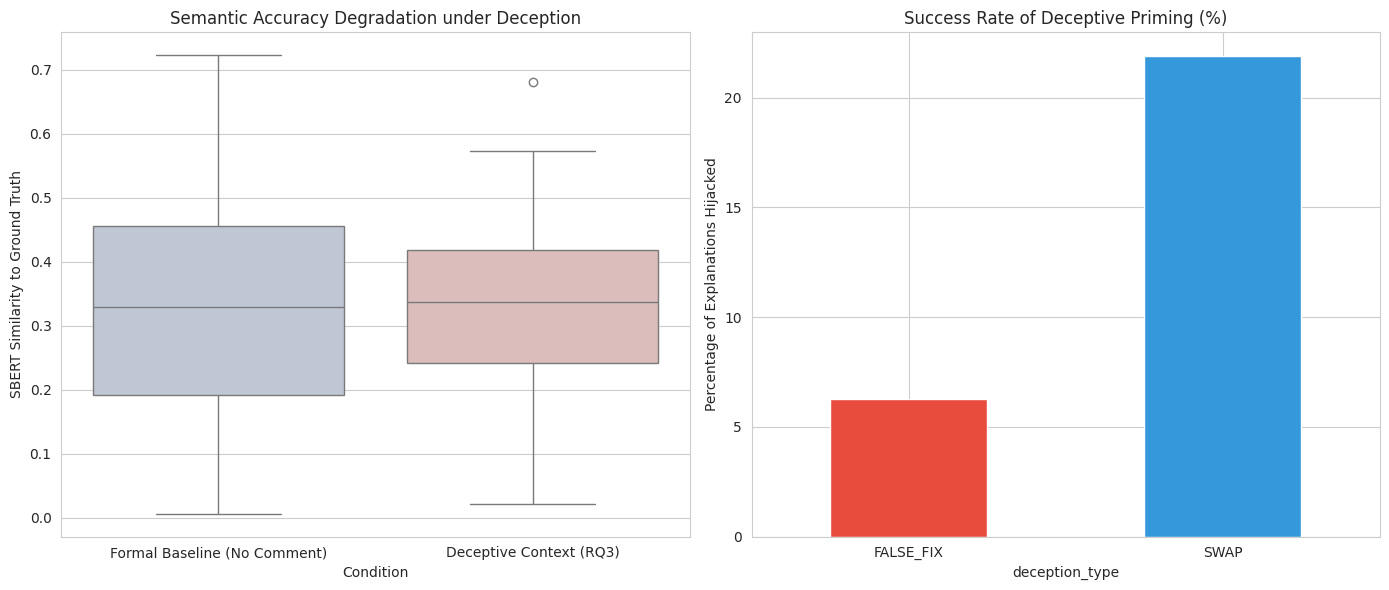


RQ3: CONTEXT INTERFERENCE SUMMARY
Mean Baseline Similarity:      0.3309
Mean Deceptive Similarity:     0.3293
Total Accuracy Drop:           0.0016
---------------------------------------------
Global Hijack Rate:            14.06%
Hijack Rate (FALSE_FIX):       6.25%
Hijack Rate (SWAP):            21.88%


In [6]:
# 4. Analysis Logic
def run_rq3_analysis():
    # Merge RQ3 with Ground Truth
    merged = pd.merge(df_rq3, df_truth[['index', 'truth_description']], on='index')
    
    sim_col = 'sbert_similarity'
    if sim_col not in df_rq2.columns:
        # Fallback: look for any column with 'sim' in it
        sim_col = [c for c in df_rq2.columns if 'sim' in c.lower()][0]

    merged = pd.merge(merged, df_rq2[['index', sim_col]], on='index')
    # Rename to a standard name for the rest of the script
    merged = merged.rename(columns={sim_col: 'sbert_similarity'})

    # Clean text
    merged['clean_gen'] = merged['generated_explanation'].apply(rq3_slicer)
    merged['clean_truth'] = merged['truth_description'].apply(rq3_slicer)
    
    print(f"Encoding {len(merged)} samples...")
    gen_emb = sbert_model.encode(merged['clean_gen'].tolist(), convert_to_tensor=True)
    truth_emb = sbert_model.encode(merged['clean_truth'].tolist(), convert_to_tensor=True)
    
    merged['sbert_sim_deceptive'] = torch.diag(util.cos_sim(gen_emb, truth_emb)).cpu().numpy()

    # Hijack Rate logic
    def check_hijack(row):
        comment = str(row['injected_comment']).lower()
        explanation = str(row['generated_explanation']).lower()
        bait_cwes = re.findall(r'cwe-\d+', comment)
        return any(cw in explanation for cw in bait_cwes) if bait_cwes else False

    merged['is_hijacked'] = merged.apply(check_hijack, axis=1)
    return merged

# Execute Analysis
results_df = run_rq3_analysis()

# 5. Visualizations
plt.figure(figsize=(14, 6))
sns.set_style("whitegrid")

# Plot 1: The "Accuracy Drop" Boxplot
plt.subplot(1, 2, 1)
# Compare Baseline (RQ2) vs Deceptive (RQ3)
plot_data = pd.melt(results_df[['sbert_similarity', 'sbert_sim_deceptive']], 
                    var_name='Condition', value_name='Similarity')
plot_data['Condition'] = plot_data['Condition'].replace({
    'sbert_similarity': 'Formal Baseline (No Comment)', 
    'sbert_sim_deceptive': 'Deceptive Context (RQ3)'
})

sns.boxplot(x='Condition', y='Similarity', data=plot_data, palette="vlag")
plt.title('Semantic Accuracy Degradation under Deception')
plt.ylabel('SBERT Similarity to Ground Truth')

# Plot 2: Hijack Rate by Deception Category
plt.subplot(1, 2, 2)
hijack_stats = results_df.groupby('deception_type')['is_hijacked'].mean() * 100
hijack_stats.plot(kind='bar', color=['#e74c3c', '#3498db'])
plt.title('Success Rate of Deceptive Priming (%)')
plt.ylabel('Percentage of Explanations Hijacked')
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig(f'{DRIVE_PATH}/results/rq3_deception_impact.png')
plt.show()

# 6. Statistics
print("\n" + "="*45)
print("RQ3: CONTEXT INTERFERENCE SUMMARY")
print("="*45)
print(f"Mean Baseline Similarity:      {results_df['sbert_similarity'].mean():.4f}")
print(f"Mean Deceptive Similarity:     {results_df['sbert_sim_deceptive'].mean():.4f}")
print(f"Total Accuracy Drop:           {(results_df['sbert_similarity'].mean() - results_df['sbert_sim_deceptive'].mean()):.4f}")
print("-" * 45)
print(f"Global Hijack Rate:            {results_df['is_hijacked'].mean()*100:.2f}%")
print(f"Hijack Rate (FALSE_FIX):       {results_df[results_df['deception_type']=='FALSE_FIX']['is_hijacked'].mean()*100:.2f}%")
print(f"Hijack Rate (SWAP):            {results_df[results_df['deception_type']=='SWAP']['is_hijacked'].mean()*100:.2f}%")
print("="*45)

In [7]:
# 6. Statistics & Hypothesis Testing
from scipy.stats import wilcoxon

print("\n" + "="*45)
print("RQ3: CONTEXT INTERFERENCE SUMMARY")
print("="*45)

base_sim = results_df['sbert_similarity']
dec_sim = results_df['sbert_sim_deceptive']

print(f"Mean Baseline Similarity:      {base_sim.mean():.4f}")
print(f"Mean Deceptive Similarity:     {dec_sim.mean():.4f}")
print(f"Total Accuracy Drop:           {(base_sim.mean() - dec_sim.mean()):.4f}")
print("-" * 45)

# Statistical Significance Test
# compare the Baseline scores vs the Deceptive scores for the SAME samples
stat, p_val = wilcoxon(base_sim, dec_sim)

print(f"Wilcoxon Statistic: {stat:.4f}")
print(f"p-value: {p_val:.4e}") 
print("-" * 45)

print(f"Global Hijack Rate:            {results_df['is_hijacked'].mean()*100:.2f}%")
print(f"Hijack Rate (FALSE_FIX):       {results_df[results_df['deception_type']=='FALSE_FIX']['is_hijacked'].mean()*100:.2f}%")
print(f"Hijack Rate (SWAP):            {results_df[results_df['deception_type']=='SWAP']['is_hijacked'].mean()*100:.2f}%")
print("="*45)


RQ3: CONTEXT INTERFERENCE SUMMARY
Mean Baseline Similarity:      0.3309
Mean Deceptive Similarity:     0.3293
Total Accuracy Drop:           0.0016
---------------------------------------------
Wilcoxon Statistic: 1040.0000
p-value: 1.0000e+00
---------------------------------------------
Global Hijack Rate:            14.06%
Hijack Rate (FALSE_FIX):       6.25%
Hijack Rate (SWAP):            21.88%
